# 03b-03 - Feature Matching

You see how one spot is found in two photographs, how wrong matches are thrown out, and how matches become tracks.

We start with every pair the software matched across the flight. Then we take one pair and do the work by hand. We match features by their descriptions, keep the matches that obey the geometry of two cameras, and chain matches through eight photographs into tracks. At the end you change the ratio test's setting.

This notebook reads the flight named in `data/flight.json`. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that the next pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sfm_tools as sfm
from matplotlib.collections import LineCollection

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight, choices = sfm.load_flight("data/flight.json")
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at "
      f"{flight['altitude_agl_m']} m, {flight['n_photos']} photographs")

the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs


## Every matched pair of the flight

The cell reads the software's list of matched pairs and draws each pair as a line between its two camera positions.

672 matched pairs   reference 672
1120.1 matches per pair   reference 1120.1


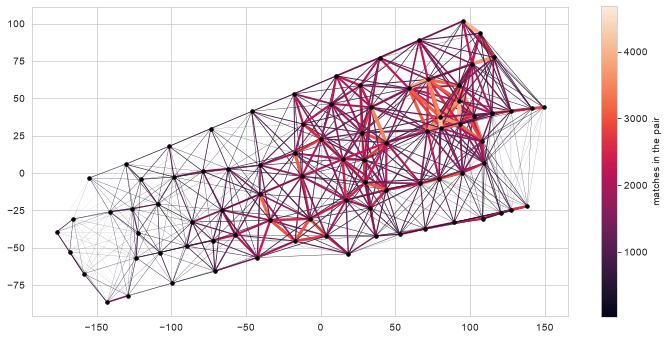

In [2]:
matched = pd.read_csv("data/pairs.csv").query("matches > 0")
photos = pd.read_csv("data/photos.csv").set_index("file")
position = photos[["easting", "northing"]] - choices["offset"]
segments = np.stack([position.loc[matched["image_a"]], position.loc[matched["image_b"]]], axis=1)
mean = matched["matches"].mean()
print(f"{len(matched)} matched pairs   reference {reference['overlap']['matched_pairs']}")
print(f"{mean:.1f} matches per pair   reference {reference['overlap']['matches_per_pair_mean']}")
fig, ax = plt.subplots(figsize=(12, 7), subplot_kw={"aspect": "equal"})
lines = LineCollection(segments, array=matched["matches"], lw=matched["matches"] / 1000)
ax.add_collection(lines)
fig.colorbar(lines, ax=ax, shrink=0.8, label="matches in the pair")
ax.scatter(position["easting"], position["northing"], s=12, color="black", zorder=3)

The software matched hundreds of pairs. Each line joins two photographs where matches survived. Thick bright lines hold thousands of matches, thin dark ones a few hundred. Short lines join neighbours on one pass over the field. Long lines join photographs from different passes that saw the same ground. The pattern of the lines is the pattern of the flight. Read the two counts, the pairs and the matches per pair. Then we do one of these pairs by hand.

## The pair

The cell loads the two photographs of the kit's pair and the software's camera positions, and measures the distance between the two cameras.

baseline 11.16 m   reference 11.16


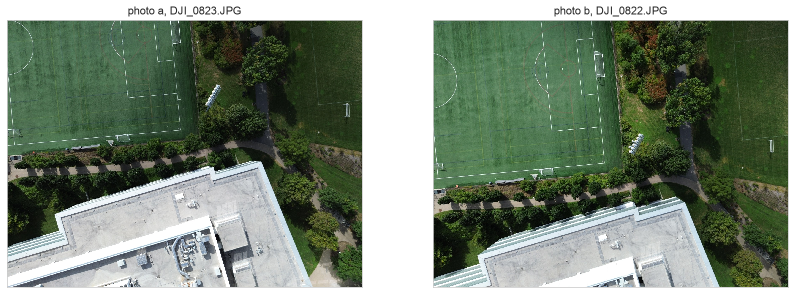

In [3]:
block = sfm.load_block("data/block.npz")
photo_a = sfm.read_image("data/photo_a.jpg")
photo_b = sfm.read_image("data/photo_b.jpg")
name_a, name_b = choices["pair"]["a"], choices["pair"]["b"]
shot_a, shot_b = choices["photos"]["a"]["shot_index"], choices["photos"]["b"]["shot_index"]
centre_a = sfm.camera_centre(block["rotation_map"][shot_a], block["translation_map"][shot_a])
centre_b = sfm.camera_centre(block["rotation_map"][shot_b], block["translation_map"][shot_b])
baseline = np.linalg.norm(centre_b - centre_a)
print(f"baseline {baseline:.2f} m   reference {reference['pair']['baseline_m']}")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sfm.show_image(axes[0], photo_a, title=f"photo a, {name_a}")
sfm.show_image(axes[1], photo_b, title=f"photo b, {name_b}")

These two photographs show the same ground from two places. The distance between the two cameras is the baseline. Read it beside the reference value the kit carries. Everything on the ground shifts a little between the pictures, and tall things shift more than low ones. That shift is parallax, and it is what gives height later on. Find the same roof corner, path and crown in both pictures. The shift is small because the baseline is short next to the flying height.

## Matching by description, with the ratio test

The cell compares every feature of photo a with every feature of photo b by their 128 numbers and keeps the clear winners.

2844 candidates at 0.8   reference 2844


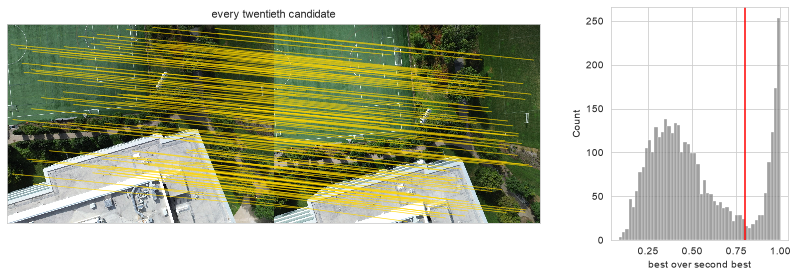

In [4]:
features = sfm.load_features("data/features_pair.npz")
h, w = photo_a.shape[:2]  # rows and columns of the kit's photographs
nearest, ratios_all = sfm.two_nearest(features["descriptors_a"], features["descriptors_b"])
ia, ib, ratios = sfm.ratio_matches(features["descriptors_a"], features["descriptors_b"], 0.8)
pa = np.column_stack(sfm.feature_pixels(features["points_a"][ia], w, h))
pb = np.column_stack(sfm.feature_pixels(features["points_b"][ib], w, h))
print(f"{len(ia)} candidates at 0.8   reference {reference['pair']['ratio_0_8']['candidates']}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), width_ratios=[3, 1])
sfm.show_image(axes[0], np.hstack([photo_a, photo_b]), title="every twentieth candidate")
axes[0].plot([pa[::20, 0], pb[::20, 0] + w], [pa[::20, 1], pb[::20, 1]], color="gold", lw=0.6)
sns.histplot(ratios_all, bins=50, ax=axes[1], color="0.5").set(xlabel="best over second best")
axes[1].axvline(0.8, color="red")

For each feature of photo a we find the two most similar features of photo b. If the best is clearly better than the second best, we keep the match. If both are about as good, the feature looks like several things, and we drop it. A lawn does exactly that. The histogram counts features by the ratio of best to second best. The pile at the right edge had no clear partner. The software cuts at 0.8 and so do we. The lines show every twentieth match.

## The geometric check

The cell fits the geometry of the two cameras to the candidates, keeps the matches that agree with it, and draws one epipolar line.

geometry kept 2614   reference 2614
software kept 2584   reference 2584


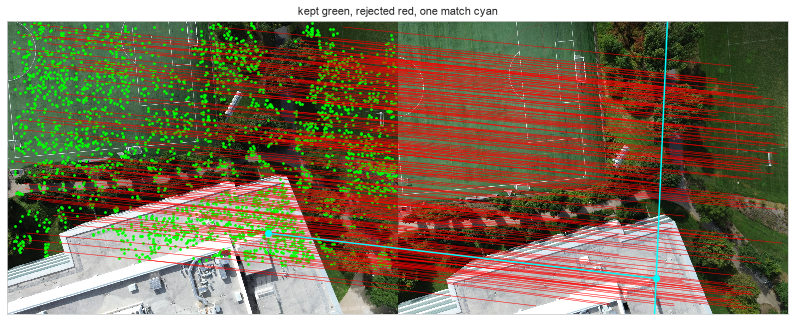

In [5]:
F, kept = sfm.fundamental_ransac(pa, pb)
row = matched[matched[["image_a", "image_b"]].isin([name_a, name_b]).all(axis=1)]
print(f"geometry kept {kept.sum()}   reference {reference['pair']['ratio_0_8']['inliers']}")
print(f"software kept {row.matches.iloc[0]}   reference {reference['pair']['software_matches']}")
first = np.flatnonzero(kept)[0]  # the first match the geometry kept
line = sfm.epipolar_lines(F, pa[[first]], w)[0]
fig, ax = plt.subplots(figsize=(14, 5.5), subplot_kw={"xlim": (0, 2 * w), "ylim": (h, 0)})
sfm.show_image(ax, np.hstack([photo_a, photo_b]), title="kept green, rejected red, one match cyan")
ax.scatter(pa[kept, 0], pa[kept, 1], s=3, color="lime")
ax.plot([pa[~kept, 0], pb[~kept, 0] + w], [pa[~kept, 1], pb[~kept, 1]], color="red", lw=0.5)
ax.plot([pa[first, 0], pb[first, 0] + w], [pa[first, 1], pb[first, 1]], c="cyan", marker="o")
ax.plot(line[:, 0] + w, line[:, 1], color="cyan")

A point in one photograph must lie on one line in the other, its epipolar line. The check fits that rule to eight random matches, counts how many agree, and repeats many times. The matches that fit the best rule are kept, in green. Red lines join the matches that failed. Look at what they join. The cyan segment is one kept match, and its right end sits on the cyan epipolar line. Our count sits near the software's, whose test had its own settings.

## From pairs to tracks

The cell chains the software's matches among eight photographs into tracks and counts them beside the software's own tracks for the same photographs.

10482 tracks by hand   reference 10482
10573 by the software   reference 10573
4.57 photographs per track   reference 4.57


<Axes: xlabel='photographs in the track', ylabel='tracks'>

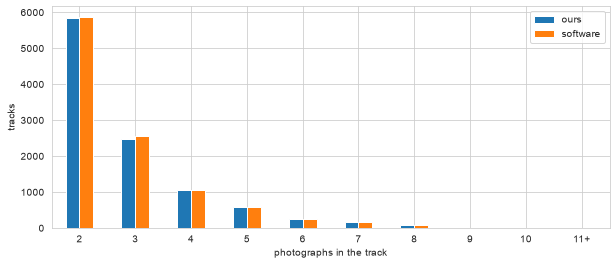

In [6]:
track_of, ours = sfm.union_find_tracks(sfm.load_matches("data/matches_group.npz"))
tracks = sfm.load_tracks("data/tracks.npz")
group_index = [block["names"].index(name) for name in choices["group"]]
seen = np.unique(tracks["point"][np.isin(tracks["shot"], group_index)], return_counts=True)[1]
group = reference["tracks"]["group"]
print(f"{len(ours)} tracks by hand   reference {group['union_find_tracks']}")
print(f"{(seen >= 2).sum()} by the software   reference {group['software_tracks_within_group']}")
mean_length = tracks["track_lengths"].mean()
print(f"{mean_length:.2f} photographs per track   reference {reference['tracks']['mean_length']}")
counts = pd.DataFrame({"ours": sfm.length_histogram(ours), "software": sfm.length_histogram(seen)})
fig, ax = plt.subplots(figsize=(10, 4))
counts.plot.bar(ax=ax, xlabel="photographs in the track", ylabel="tracks", rot=0)

A match joins two photographs. A track joins every photograph that saw one ground point. Chaining matches is all it takes. A feature matched to two others makes a track of three. Count our tracks beside the software's for the same eight photographs. The two counts are close but not equal, because the software also chained through photographs outside the eight. The bars count tracks by how many photographs they run through. Then read the whole flight's mean, how many photographs a typical point was seen in.

## Your turn

The ratio test's cut is a dial. The cell repeats the matching and the geometric check at the marked ratio and prints the candidates, the inliers (the matches the geometry kept) and the share kept. Try 0.7, then 0.9, and read each run against the run at 0.8. Run the cell as it is, then change the marked value and run it again.

Which of the three numbers moved most as you turned the dial, and which setting would you give the software? Write your answer in one or two sentences. The answer comes in Friday's post, not in the kit.

In [7]:
RATIO = 0.8  # change me: 0.7, then 0.9
ia, ib, ratios = sfm.ratio_matches(features["descriptors_a"], features["descriptors_b"], RATIO)
pa = np.column_stack(sfm.feature_pixels(features["points_a"][ia], w, h))
pb = np.column_stack(sfm.feature_pixels(features["points_b"][ib], w, h))
F, kept = sfm.fundamental_ransac(pa, pb)
print(f"ratio {RATIO}   {len(ia)} candidates, {kept.sum()} inliers, share kept {kept.mean():.3f}")

ratio 0.8   2844 candidates, 2614 inliers, share kept 0.919


## Check your understanding

1. The ratio test compares the best match with the second best instead of asking how good the best is on its own. Why does that help on a lawn?
2. What is an epipolar line, and why can the partner of a point in photo a lie only on one line in photo b?
3. The geometric check fits eight random matches at a time instead of all candidates at once. Why would one fit through all of them go wrong?
4. A track of length two gives one ground point two rays. What does a track of length eight give the adjustment that the short one cannot?

## Where we are

You matched two photographs by the numbers around their features, watched the ratio test drop the doubtful ones, and let the geometry of two cameras throw out matches that looked right and were wrong. You chained matches through eight photographs into tracks, and every track is one ground point waiting for its coordinates. In 03b-04 the tracks become points in space and every camera finds its place.

## Further resources

Nothing in this course requires anything below.

- Distinctive Image Features from Scale-Invariant Keypoints, David Lowe, International Journal of Computer Vision, 2004, the paper behind the descriptor and the ratio test: https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf
- Random Sample Consensus, Martin Fischler and Robert Bolles, Communications of the ACM, 1981, the paper behind the geometric check: https://dl.acm.org/doi/10.1145/358669.358692
- Computer Vision: Algorithms and Applications, Richard Szeliski, Springer, second edition 2022, free online, feature matching in chapter 7 and two-view geometry in chapter 11: https://szeliski.org/Book/
- OpenSfM documentation, the matching and the tracks inside OpenDroneMap: https://opensfm.org/docs/

The photographs, the software's files and the products are the course's own flight, published under CC BY 4.0.